In [2]:
import pandas as pd  
from sklearn.datasets import fetch_california_housing

import numpy as np
 
import matplotlib.pyplot as plt 
import seaborn as sns 


## **step 1. load dataset**


In [33]:
housing= fetch_california_housing()

df=pd.DataFrame(data=housing.data,columns=housing.feature_names)
print(f'dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

dataset shape: 20640 rows x 8 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## **step 2. Explore and understand the dataset** 

In [27]:
print("==Data types & non-null counts===")
df.info()

==Data types & non-null counts===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [30]:
print("== Statistical report==")
df.describe()

== Statistical report==


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


## **step 3. visulise the dataset**

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

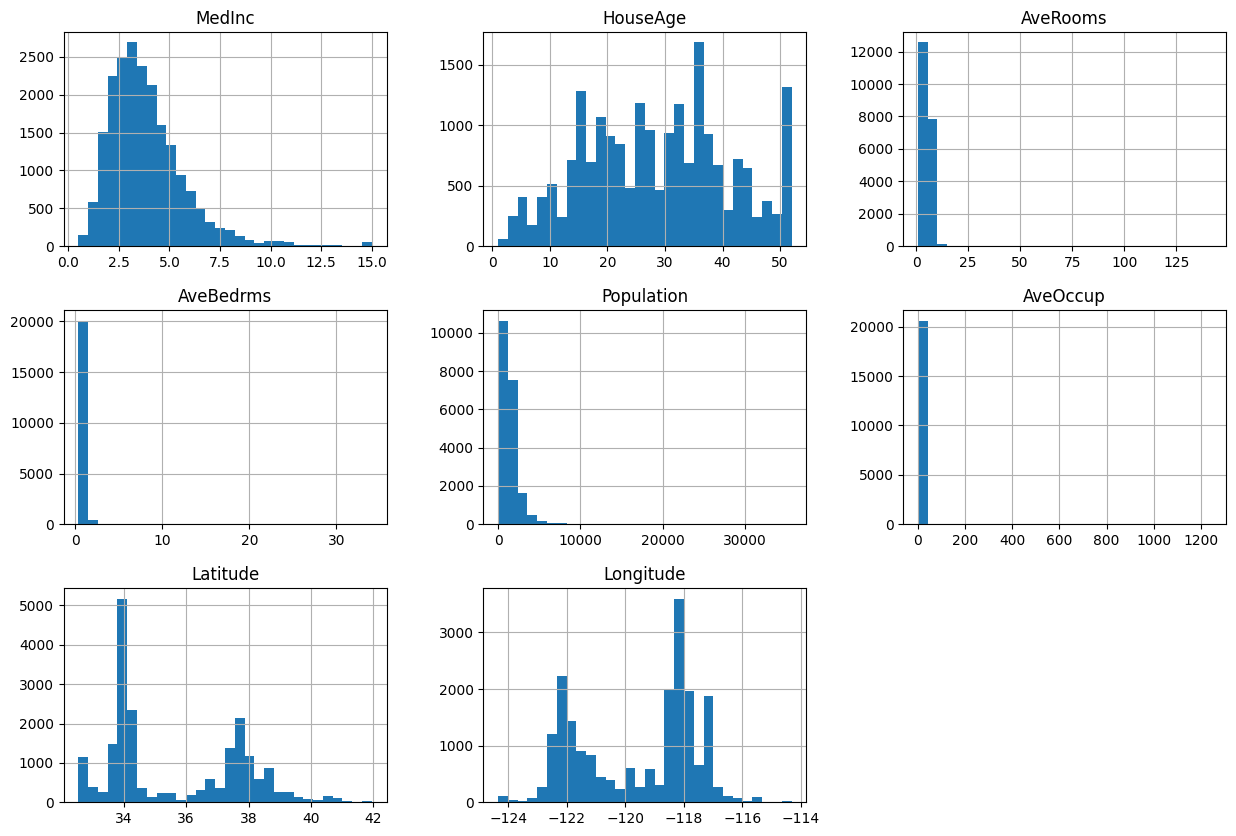

In [54]:
df.hist(figsize=(15,10),bins=30)



              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   

            Latitude  Longitude  
MedInc     -0.079809  -0.015176  
HouseAge    0.011173  -0.108197  
AveRooms    0.106389  -0.027540  
AveBedrms   0.069721   0.013344  
Population -0.108785   0.099773  
AveOccup    0.002366   0.002476  
Latitude    1.000000  -0.924664  
Longitude  -0.924664   1.000000  


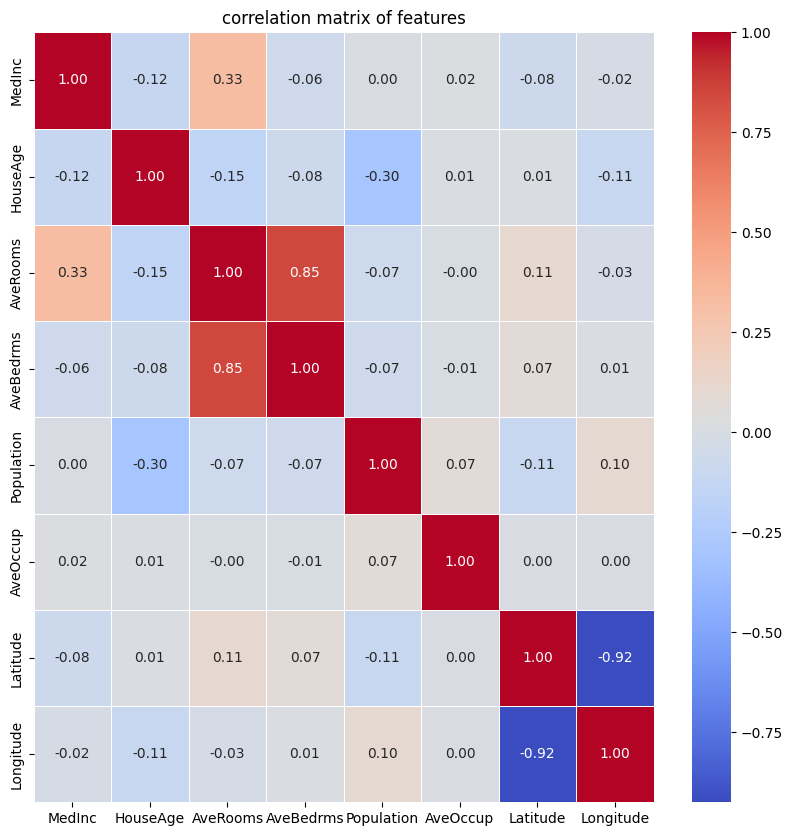

In [59]:
corr_matrix=df.corr(numeric_only=True) # this will work as it drops columns have non numeric data
print(corr_matrix)
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation matrix of features')
plt.show()

**Feature engineering :**

In [67]:
TARGET=housing.target

In [71]:
#can i calculate cost of one room 
df["price per room"]=TARGET/df['AveRooms']
print(' new feature created :')
print('            -> price per room')

 new feature created :
            -> price per room


In [80]:
#independent features and dependent features 
x=df ## all features 
y=housing.target # all targets(outputs)

print(f'features (x): {x.shape[1]} columns')
print(f'target (y):{y.shape}')

features (x): 9 columns
target (y):(20640,)


In [85]:
# train test my data 

from sklearn.model_selection import  train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [95]:
# standerdizing the dataset
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()# initialisiation
x_train_sc=scaler.fit_transform(x_train)
x_test_sc=scaler.transform(x_test)

print(f'Training set size : {x_train.shape[0]:,} samples')
print(f' Test    set size : {x_test.shape[0]:,} sample')


Training set size : 16,512 samples
 Test    set size : 4,128 sample


In [117]:
from sklearn.linear_model import LinearRegression,Ridge,ElasticNet
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score


In [107]:
#---------model 1 . Linear Regression--------------
lr=LinearRegression()
lr.fit(x_train_sc,y_train)
print('Linear Regression trained!')

#model 2: ridge Regression
rid=Ridge()
rid.fit(x_train_sc,y_train)
print('ridge regression trained!')

elnet=ElasticNet()
elnet.fit(x_train_sc,y_train)
print('Elastic net trained!')


Linear Regression trained!
ridge regression trained!
Elastic net trained!


In [118]:
def evaluate_model(name , model, x_test_data,y_test_data):
    y_pred = model.predict(x_test_data)
    
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    mape=mean_absolute_percentage_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    print(f'\n{'='*50}')
    print(f'📌 {name}')
    print(f'{'='*50}')
    print(f'mean absolute error: {mse:.4f}')
    print(f'{'--'*30}')
    print(f'mean squared error: {mse:.4f}')
    print(f'{'--'*30}')
    print(f'mean absolute percentage error: {mape:.4f} %')
    print(f'{'--'*30}')
    print(f'R2 score: {r2:.4f}')
    print()
    print(f'{'**'*30}')

lr_report=evaluate_model('linear regression',lr,x_test_sc,y_test)
rid_report=evaluate_model('ridge regression',rid,x_test_sc,y_test)
# elnet=evaluate_model('elasticnet regression',elnet,x_test_sc,y_test)



📌 linear regression
mean absolute error: 0.1075
------------------------------------------------------------
mean squared error: 0.1075
------------------------------------------------------------
mean absolute percentage error: 0.1201 %
------------------------------------------------------------
R2 score: 0.9180

************************************************************

📌 ridge regression
mean absolute error: 0.1075
------------------------------------------------------------
mean squared error: 0.1075
------------------------------------------------------------
mean absolute percentage error: 0.1201 %
------------------------------------------------------------
R2 score: 0.9180

************************************************************


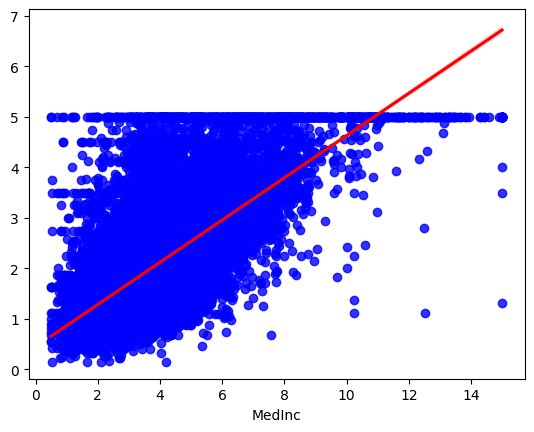

In [115]:
# regression plt : it draws the best fit line especially use for linear regression
sns.regplot(x="MedInc",y=y,data=df,scatter_kws={"color":"blue"},line_kws={"color":"red"})
plt.show()

In [119]:
parameter={
    'fit_intercept':[True,False],
    'positive':[True,False]
}

In [122]:
from sklearn.model_selection import GridSearchCV
ridgecv=GridSearchCV(rid,param_grid=parameter,cv=5,scoring='neg_mean_squared_error')


In [123]:
ridgecv.fit(x_train,y_train)
print("Best parameters found: ",ridgecv.best_params_)

Best parameters found:  {'fit_intercept': True, 'positive': False}


In [126]:
parameters={'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv=GridSearchCV(rid,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

In [127]:
ridge_pred=ridgecv.predict(x_test)



In [128]:
ridgecv.best_params_

{'alpha': 90}

In [129]:
ridgecv.best_score_

np.float64(-0.10561761211617755)

In [130]:
score=r2_score(y_test,ridge_pred)
score

0.9174712140278953